# Internações × Qualidade do Ar — Rio de Janeiro

**Objetivo:** consolidar e sincronizar séries temporais diárias de qualidade do ar (estações QUALIAR/DataRio) com registros de internações por doenças respiratórias (DATASUS) para análise exploratória e modelagem preditiva.

**Escopo:**
- Agregar séries diárias de poluentes e variáveis meteorológicas às contagens diárias de internações respiratórias;
- Gerar features temporais (lags, médias móveis, janelas causais), indicadores de calendário e avaliar impacto de poluentes nas internações;
- Estimar modelos preditivos (Random Forest, HistGradientBoosting, LSTM) e calcular intervalos de incerteza (conformal pairs).

**CID-10 considerados:** J15, J18 (pneumonias), J21 (bronquiolite), J96 (insuficiência respiratória), J40–J42 (bronquites), J43–J44 (DPOC/enfisema), J45–J46 (asma).


## 1) Configurações e importações
Breve setup de bibliotecas utilizadas.

In [1]:
from __future__ import annotations
from pathlib import Path
from typing import Tuple, List, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.tree import export_text

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import re


## 2) Unificação dos datasets (Internações × Ambiente)
Carrega CSVs do GitHub (QUALIAR/DataRio e DATASUS), faz *merge* por data e salva um CSV consolidado.

In [2]:
url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/datasus/INTER_DR_RJ_SEAZONALITY.csv"
url_qualiar     = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/main/data/DataRio/QUALIAR_RIO_DE_JANEIRO_TRATADO.csv"

df_internacoes = pd.read_csv(url_internacoes, encoding="utf-8")
df_qualiar     = pd.read_csv(url_qualiar,     encoding="utf-8")

df_unificado = (
    pd.merge(df_qualiar, df_internacoes, on="data_dia", how="inner")
      .sort_values("data_dia")
      .reset_index(drop=True)
)

df_unificado.drop(columns=["ano", "mes", "dia"], inplace=True, errors="ignore")

print("Dimensões do unificado:", df_unificado.shape)
print("Intervalo de datas:", df_unificado["data_dia"].min(), "→", df_unificado["data_dia"].max())
print("\nColunas:", df_unificado.columns.tolist())
display(df_unificado.head())
print("\nTipos de dados:")
print(df_unificado.dtypes)


Dimensões do unificado: (4748, 40)
Intervalo de datas: 2012-01-01 → 2024-12-30

Colunas: ['data_dia', 'chuva', 'temp', 'ur', 'co', 'no', 'no2', 'nox', 'so2', 'o3', 'pm10', 'pm2_5', 'temp_min', 'temp_max', 'AQI', 'Qualidade_do_Ar', 'y', 'year', 'month', 'dow', 'doy', 'is_weekend', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'y_lag_1', 'y_lag_2', 'y_lag_3', 'y_lag_7', 'roll7_mean', 'roll7_std', 'roll14_mean', 'roll14_std', 'roll30_mean', 'roll30_std', 'stl_trend', 'stl_season']


,data_dia,chuva,temp,ur,co,no,no2,nox,so2,o3,...,y_lag_3,y_lag_7,roll7_mean,roll7_std,roll14_mean,roll14_std,roll30_mean,roll30_std,stl_trend,stl_season
0,2012-01-01,0.849992,25.835,92.165,0.215703,1.256189,4.184802,2.770516,1.567692,6.469835,...,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,0.000000,645.896962,-197.197248
1,2012-01-02,0.891094,22.836,95.589,0.181572,1.884591,4.419030,3.019050,1.189413,6.013862,...,NaN,NaN,507.000000,0.000000,507.000000,0.000000,507.000000,0.000000,645.554593,-34.355772
2,2012-01-03,0.024357,24.948,76.139,0.165267,2.021231,4.512331,3.108324,2.004412,5.246714,...,NaN,NaN,617.500000,156.270599,617.500000,156.270599,617.500000,156.270599,645.212035,-71.854513
3,2012-01-04,0.047493,26.006,72.904,0.170964,2.175012,5.096621,3.324094,1.736737,6.754888,...,507.0,NaN,554.666667,155.094595,554.666667,155.094595,554.666667,155.094595,644.869285,-144.550309
4,2012-01-05,-0.000000,26.498,75.514,0.169471,2.007440,4.843477,3.181217,1.715770,7.889395,...,728.0,NaN,520.000000,144.372204,520.000000,144.372204,520.000000,144.372204,644.526341,-173.562390



Tipos de dados:
data_dia            object
chuva              float64
temp               float64
ur                 float64
co                 float64
no                 float64
no2                float64
nox                float64
so2                float64
o3                 float64
pm10               float64
pm2_5              float64
temp_min           float64
temp_max           float64
AQI                float64
Qualidade_do_Ar    float64
y                    int64
year                 int64
month                int64
dow                  int64
doy                  int64
is_weekend           int64
dow_sin            float64
dow_cos            float64
month_sin          float64
month_cos          float64
doy_sin            float64
doy_cos            float64
y_lag_1            float64
y_lag_2            float64
y_lag_3            float64
y_lag_7            float64
roll7_mean         float64
roll7_std          float64
roll14_mean        float64
roll14_std         float64
roll30_mean

### 2.1) Persistir CSV consolidado

In [3]:
project_root = Path().resolve()
output_dir = project_root / "data"
output_dir.mkdir(parents=True, exist_ok=True)
output_csv_path = output_dir / "INTERNACOES_x_QUALIAR_NEW.csv"
df_unificado.to_csv(output_csv_path, index=False, encoding="utf-8")
print("Arquivo salvo em:", output_csv_path)


Arquivo salvo em: C:\Users\jhter\OneDrive - cefet-rj.br\qualiar\notebooks\data\INTERNACOES_x_QUALIAR_NEW.csv


## 3) Série temporal das internações
Visualiza a série diária com média móvel de 7 dias e a média global.

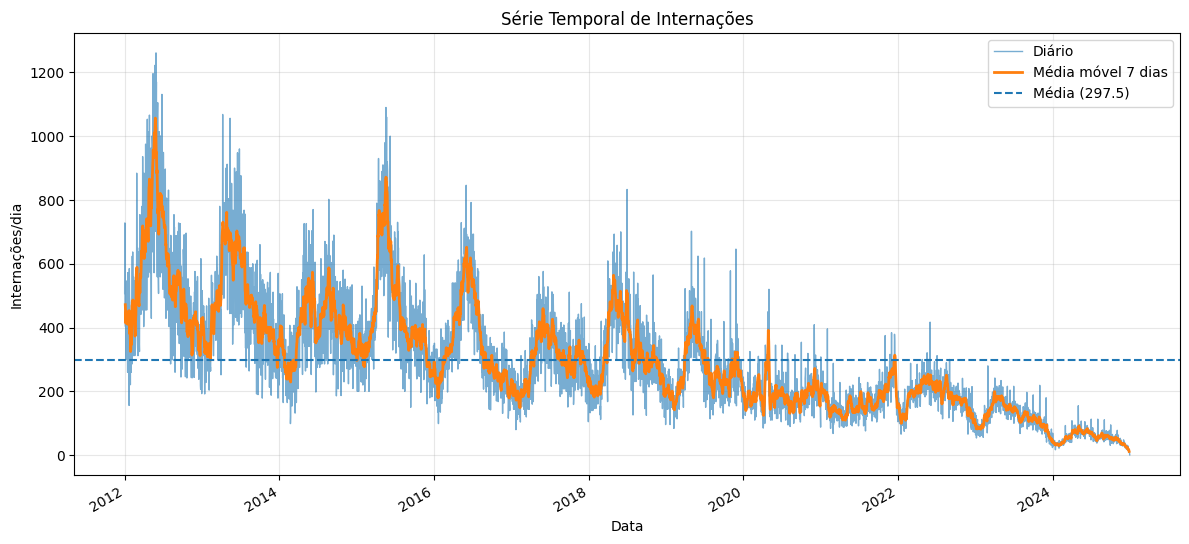

In [4]:
ts = df_unificado.set_index(pd.to_datetime(df_unificado['data_dia']))['y']

plt.figure(figsize=(12, 6))
plt.plot(ts.index, ts.values, label='Diário', alpha=0.6, linewidth=1)
plt.plot(ts.index, ts.rolling(7, center=True).mean(), label='Média móvel 7 dias', linewidth=2)
mean_val = ts.mean()
plt.axhline(mean_val, linestyle='--', linewidth=1.5, label=f'Média ({mean_val:.1f})')
plt.title('Série Temporal de Internações')
plt.xlabel('Data'); plt.ylabel('Internações/dia')
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.gcf().autofmt_xdate()


## 4) Engenharia de *features* (médias móveis causais)
Cria colunas de médias móveis para poluentes/variáveis ambientais com defasagem causal.

In [5]:
# garantir ordenação temporal
df_unificado["data_dia"] = pd.to_datetime(df_unificado["data_dia"])
df_unificado = df_unificado.sort_values("data_dia").reset_index(drop=True)

specs = [
    ("o3",   150, 0),
    ("o3",   150, 3),
    ("o3",   150, 5),
    ("no",    60, 0),
    ("so2",  150, 3),
    ("so2",  150, 7),
    ("nox",   60, 0),
    ("no2",   30, 0),
    ("pm10",  30, 0),
    ("pm2_5",  7, 0),
    ("co",     3, 7),
]

for var, window, shift in specs:
    if var not in df_unificado.columns:
        continue
    col_name = f"{var}_r{window}_s{shift}_mean"
    df_unificado[col_name] = (
        df_unificado[var].shift(shift)
        .rolling(window=window, min_periods=window)
        .mean()
    )

print("Novas colunas criadas (amostra):")
print([c for c in df_unificado.columns if c.endswith('_mean')][:10])


Novas colunas criadas (amostra):
['roll7_mean', 'roll14_mean', 'roll30_mean', 'o3_r150_s0_mean', 'o3_r150_s3_mean', 'o3_r150_s5_mean', 'no_r60_s0_mean', 'so2_r150_s3_mean', 'so2_r150_s7_mean', 'nox_r60_s0_mean']


## 5) Funções auxiliares — calendário contínuo e imputação causal
Cria calendário diário sem buracos e **não** preenche o alvo (y).

In [6]:
def make_daily_frame(df: pd.DataFrame,
                     date_col: str,
                     target_col: str,
                     ffill_limit: int = 14,
                     categorical_cols: List[str] | None = None) -> pd.DataFrame:
    data = df.copy()
    data[date_col] = pd.to_datetime(data[date_col], errors='coerce')
    data = data.sort_values(date_col).set_index(date_col)
    full_idx = pd.date_range(data.index.min(), data.index.max(), freq='D')
    data = data.reindex(full_idx)
    if categorical_cols is None:
        categorical_cols = []
    num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    if target_col in num_cols:
        num_cols.remove(target_col)
    cat_cols = [c for c in categorical_cols if c in data.columns]
    for c in num_cols + cat_cols:
        data[f"{c}_missing"] = data[c].isna().astype(int)
    for c in num_cols:
        data[c] = data[c].ffill(limit=ffill_limit)
    for c in cat_cols:
        data[c] = data[c].ffill(limit=min(3, ffill_limit))
    return data


## 6) Janelas causais (rolling window) → dataset tabular
Aplica janela deslizante e achata para colunas do tipo `feat_t-1`, `feat_t-2`, ...

In [7]:
def apply_rolling_window(time_series_array,
                         initial_time_step,
                         max_time_step,
                         window_size,
                         target_idx):
    assert 0 <= target_idx < time_series_array.shape[1]
    assert initial_time_step >= 0
    assert max_time_step >= initial_time_step
    start = initial_time_step
    sub_windows = (
        start +
        np.expand_dims(np.arange(window_size), 0) +
        np.expand_dims(np.arange(max_time_step + 1), 0).T
    )
    X = time_series_array[sub_windows]
    y = time_series_array[window_size:(max_time_step+window_size+1):1, target_idx]
    idx_y_train_not_nan = np.where(~np.isnan(y))[0]
    assert len(idx_y_train_not_nan) == len(y), 'Há y NaN — ajuste a construção de janelas.'
    _ = np.unique(np.where(np.isnan(X)))
    return X, y


In [8]:
def rolling_to_tabular(df_windowed: pd.DataFrame,
                       window_size: int,
                       target_col: str,
                       date_index: pd.DatetimeIndex) -> Tuple[pd.DataFrame, np.ndarray]:
    cols = df_windowed.columns.tolist()
    target_idx = cols.index(target_col)
    A = df_windowed.to_numpy()
    max_ts = len(df_windowed) - window_size - 1
    X3d, y = apply_rolling_window(A, 0, max_ts, window_size, target_idx)
    ns, w, nf = X3d.shape
    X2d = X3d.reshape(ns, w * nf)
    names = []
    for lag in range(1, window_size+1):
        for c in cols:
            names.append(f"{c}_t-{lag}")
    idx = date_index[window_size:(max_ts+window_size+1)]
    X = pd.DataFrame(X2d, columns=names, index=idx)
    return X, y


## 7) Métricas e pesos de recência
Funções utilitárias para avaliação e ponderação temporal.

In [9]:
def make_recency_weights(index: pd.DatetimeIndex, low: float = 0.5, high: float = 1.5) -> pd.Series:
    t = (index - index.min()).days.astype(float)
    w = low + (high - low) * (t - t.min()) / (t.max() - t.min() + 1e-9)
    return pd.Series(w, index=index).clip(lower=low, upper=high)

def smape(y, yhat):
    y, yhat = np.asarray(y, dtype=float), np.asarray(yhat, dtype=float)
    return 100*np.mean(2*np.abs(yhat - y)/(np.abs(y)+np.abs(yhat)+1e-9))

def wmape(y, yhat):
    y, yhat = np.asarray(y, dtype=float), np.asarray(yhat, dtype=float)
    return 100*np.sum(np.abs(yhat - y))/np.sum(np.abs(y)+1e-9)

def evaluate_predictions(y_true, y_pred) -> Dict[str, float]:
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred),
        'sMAPE': smape(y_true, y_pred),
        'WMAPE': wmape(y_true, y_pred),
    }


## 8) Seleção de features por *Permutation Importance*
Seleciona as `k` melhores variáveis no último *fold* (mais recente).

In [10]:
def select_top_features(X: pd.DataFrame, y: np.ndarray, pre: ColumnTransformer,
                        n_splits: int = 4, random_state: int = 42, k: int = 8) -> List[str]:
    tscv = TimeSeriesSplit(n_splits=n_splits)
    base_rf = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=10,
                                    min_samples_split=10, max_features='sqrt',
                                    random_state=random_state, n_jobs=-1)
    ttr = TransformedTargetRegressor(regressor=base_rf, func=np.log1p, inverse_func=np.expm1)
    pipe = Pipeline([('pre', pre), ('rf', ttr)])
    folds = list(tscv.split(X))
    tr_idx, va_idx = folds[-1]
    Xtr, Xva = X.iloc[tr_idx], X.iloc[va_idx]
    ytr, yva = y[tr_idx], y[va_idx]
    pipe.fit(Xtr, ytr)
    imp = permutation_importance(pipe, Xva, yva, n_repeats=10, random_state=random_state,
                                 scoring='neg_mean_absolute_error')
    importances = pd.Series(imp.importances_mean, index=X.columns).sort_values(ascending=False)
    return importances.head(k).index.tolist()


## 9) Random Forest simplificado (com TTR) e busca enxuta
Modelo com capacidade limitada para reduzir *overfitting*.

In [11]:
def tune_and_fit_rf_simplified(X: pd.DataFrame, y: np.ndarray,
                               preprocessor: ColumnTransformer,
                               n_splits: int = 5,
                               random_state: int = 42) -> Pipeline:
    base_rf = RandomForestRegressor(
        n_estimators=400,
        max_depth=12,
        min_samples_leaf=10,
        min_samples_split=10,
        max_features='sqrt',
        bootstrap=True,
        n_jobs=-1,
        random_state=random_state
    )
    ttr = TransformedTargetRegressor(regressor=base_rf, func=np.log1p, inverse_func=np.expm1)
    pipe = Pipeline([('pre', preprocessor), ('rf', ttr)])
    param_dist = {
        'rf__regressor__n_estimators': [300, 400, 600],
        'rf__regressor__max_depth': [8, 12, 16],
        'rf__regressor__min_samples_leaf': [5, 10, 20],
        'rf__regressor__min_samples_split': [5, 10, 20],
        'rf__regressor__max_features': ['sqrt', 0.5],
    }
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rec_w = make_recency_weights(X.index, low=0.7, high=1.3).values
    search = RandomizedSearchCV(pipe, param_dist, n_iter=12, cv=tscv,
                                scoring='neg_mean_absolute_error', n_jobs=-1,
                                random_state=random_state, refit=True, verbose=0)
    search.fit(X, y, rf__sample_weight=rec_w)
    return search.best_estimator_


## 10) Inspeção de árvore e gráficos de previsão
Funções para auditar regras e visualizar observado × previsto.

In [12]:
def print_one_tree(model: Pipeline, feature_names: List[str], estimator_idx: int = 0) -> None:
    rf = model.named_steps['rf'].regressor_
    tree = rf.estimators_[estimator_idx]
    txt = export_text(tree, feature_names=feature_names[:tree.n_features_in_])
    print(txt)


In [13]:
def predict_and_plot(model: Pipeline, X: pd.DataFrame, y: np.ndarray, title: str) -> Dict:
    y_hat = model.predict(X)
    y_hat = np.clip(y_hat, 0, None)
    m = evaluate_predictions(y, y_hat)
    dfp = pd.DataFrame({'y_true': y, 'y_pred': y_hat}, index=X.index)
    plt.figure(figsize=(12,5))
    plt.plot(dfp.index, dfp['y_true'], label='Observado', lw=1.2)
    plt.plot(dfp.index, dfp['y_pred'], label='Previsto (RF-TTR)', lw=1.2)
    plt.title(title); plt.xlabel('Data'); plt.ylabel('Internações / dia')
    plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()
    return {'metrics': m, 'pred_df': dfp}


## 11) Pipeline principal com janelas causais
Constrói calendário contínuo, cria janelas, seleciona ~k *features*, ajusta RF e avalia em treino e teste.

In [14]:
def run_pipeline_rf_rolling(df_unificado: pd.DataFrame,
                            date_col: str = 'data_dia',
                            target_col: str = 'y',
                            categorical_cols: List[str] = ('Qualidade_do_Ar',),
                            window_size: int = 14,
                            test_size: float = 0.2,
                            gap_days: int = 7,
                            k_features: int = 12,
                            random_state: int = 42) -> Dict:
    base = make_daily_frame(df_unificado, date_col=date_col, target_col=target_col,
                            ffill_limit=14, categorical_cols=list(categorical_cols))
    drop_regex = re.compile(r'^(y_?(lag|ma|mm|rolling|roll|shift|media|soma|sum))|(_lag\d+)$', re.IGNORECASE)
    cols_to_drop = [c for c in base.columns if drop_regex.search(c)]
    base = base.drop(columns=cols_to_drop, errors='ignore')
    feat_cols = [c for c in base.columns if c != target_col]
    X_full, y_full = rolling_to_tabular(base[feat_cols + [target_col]],
                                        window_size=window_size,
                                        target_col=target_col,
                                        date_index=base.index)
    n = len(X_full)
    cut = int(np.floor((1 - test_size) * n))
    train_idx = slice(0, max(cut - gap_days, 0))
    test_idx  = slice(cut, n)
    X_train, y_train = X_full.iloc[train_idx], y_full[train_idx]
    X_test,  y_test  = X_full.iloc[test_idx],  y_full[test_idx]
    cat_cols = [c for c in X_train.columns for base_c in categorical_cols if c.startswith(f"{base_c}_t-")]
    num_cols = [c for c in X_train.columns if c not in cat_cols]
    pre = ColumnTransformer(
        transformers=[
            ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), num_cols),
            ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                              ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_cols),
        ], remainder='drop')
    topk_raw = select_top_features(X_train, y_train, pre, n_splits=4, random_state=random_state, k=k_features)
    must = [f'y_t-{lag}' for lag in (1, 7, 14) if f'y_t-{lag}' in X_train.columns]
    topk = list(dict.fromkeys(must + topk_raw))[:max(k_features, len(must))]
    X_train_sel = X_train[topk]
    X_test_sel  = X_test[topk]
    pre_sel = ColumnTransformer(
        transformers=[
            ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), [c for c in topk if c not in cat_cols]),
            ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                              ('ohe', OneHotEncoder(handle_unknown='ignore'))]), [c for c in topk if c in cat_cols]),
        ], remainder='drop')
    best_model = tune_and_fit_rf_simplified(X_train_sel, y_train, preprocessor=pre_sel,
                                            n_splits=5, random_state=random_state)
    train_res = predict_and_plot(best_model, X_train_sel, y_train, 'Real x Previsto — RF (Treino)')
    test_res  = predict_and_plot(best_model,  X_test_sel,  y_test,  'Real x Previsto — RF (Teste)')
    print('\n===== Árvore 0 do RF (resumo) =====')
    print_one_tree(best_model, feature_names=X_train_sel.columns.tolist(), estimator_idx=0)
    return {
        'model': best_model,
        'features_kept': topk,
        'train_metrics': train_res['metrics'],
        'test_metrics':  test_res['metrics'],
        'train_pred_df': train_res['pred_df'],
        'test_pred_df':  test_res['pred_df'],
    }


## 12) Execução do pipeline (exemplo)
Filtra período, define parâmetros e executa o modelo Random Forest.

In [ ]:
df_unificado2 = df_unificado[df_unificado.get('year', 9999) <= 2021] if 'year' in df_unificado.columns else df_unificado.copy()
out = run_pipeline_rf_rolling(
    df_unificado2,
    date_col='data_dia',
    target_col='y',
    categorical_cols=('Qualidade_do_Ar',),
    window_size=14,
    test_size=0.2,
    gap_days=7,
    k_features=30
)
print('Features usadas:', out['features_kept'])
print('Treino:', out['train_metrics'])
print('Teste :', out['test_metrics'])
